# Clustering and KMeans
MATH 3080 Foundations of Data Science

Reading
* James et al., 12.1 The Challenge of Unsupervised Learning
* James et al., 12.4 Clustering Methods
* James et al., 12.4.1 K-Means Clustering

## Clustering models

<img src="https://raw.githubusercontent.com/drolsonmi/math3480/refs/heads/main/Notes/Images/3480_ML_Landscape.png" width=550 alt="Machine Learning Landscape">

Unsupervised models deal with unlabeled data (no predetermined answers).


In [ ]:
display(cluster_figure)

 This leads to a number of issues we didn't have to deal with before:
- How do you know if it's a reliable model?
- Method of grouping/clustering is arbitrary

The performance of a cluster model can't be evaluated as Supervised models, which compare the model's results with pre-labeled data. However, clustering models are unsupervised, so generally have no pre-labeled to compare.

The secret will be to look at qualities of the clusters formed by the model. For example, how big are the clusters? How does the distribution of one cluster compare to other clusters? Here, we will look at external indices and internal indices.
- An __external index__ looks at the distribution and boundaries of one cluster to those of other clusters. This means we generally base the evaluation on a known cluster structure (labels).
- An __internal index__ looks at the individual cluster without any external information. This is not dependent on any pre-known structure.

A few common evaluations:
- Within-Cluster Sum of Squares (WCSS) and the Elbow Method
* Silhouette index
* Dunn index
* R-squared index
* Davies-Bouldin index
* Hartigan index
* Root-mean-square standard deviation (RMSSTD)

We'll talk about the WCSS here and the Silhouette index in MATH 3480. The others you can learn as you delve deeper into Data Science.

What are the goals of a clustering model?
1. Minimize distance between points in a cluster
2. Maximize distance between clusters (which means we minimize the number of clusters)

### WCSS and the Elbow Method

The most well-used method of evaluating the quality of a clustering model is the __WCSS__ (Within-cluster Sum of Squares) metric in combination with the __"Elbow Method"__.

#### WCSS

* Measure the squared distance from each point to the nearest centroid
* Take the sum of these squared distances

$$WCSS = \sum_{i=1}^k \sum_{x\in C_i} ||x-\mu_i||^2$$

The WCSS is the metric of the total squared distance from points to their centroids. We want to minimize these distances. Of course, the more centroids we have, the lower these distances will be. But that isn't always better. At some point, adding more centroids is meaningless.

This is where the __Elbow Method__ is useful.

#### The Elbow Method

Imagine that we begin our model with $k=1$ cluster, then increase to $k=2$, then to $k=3$, and so on. As $k$ increases, the spacing between points within clusters (i.e. the WCSS) decreases significantly.

At some point, increasing $k$ will actually stop causing the WCSS to decreasing significantly. It may still drop, but only slightly. When this happens, the gains in WCSS are minimal as $k$ increases, so it is meaningless to increase $k$ any further. Graphically, this forms an "elbow" in the WCSS graph. *This "elbow" indicates the optimal value of $k$.*

In [ ]:
display(elbow_figure)

Again, our goal isn't to find the "right" answer. Our goal is to find some patterns in the data. This method helps us to see similarities between certain characteristics.

To best understand how the WCSS metric and the Elbow Method work, let's learn a model and apply it to that model. As we learn the K-Means model, we'll learn how to apply it in 2 dimensions. However, remember that these distances can be applied in multiple dimensions. This helps us to evaluate multiple variables and find clusters with similar characteristics among our data.

## K-Means Model

The K-Means model is a classic clustering method and is commonly used to introduce students to clustering techniques. The kMeans algorithm was proposed in 1957 as a technique for pulse-code modulation (a method to digitally represent analog signals). It has become a standard in clustering models.

### K-Means Algorithm

It is based on the idea of finding the middle of a cluster and then grouping all datapoints to the nearest cluster.

1. Determine the number of centroids needed for your data
2. Randomly assign points to a cluster
3. Find the center of your clusters and move your centroids to those centers
4. Measure the distance from every point to each centroid and assign each point to the nearest centroid
5. Repeat steps 3-4 until the updates to your centroids fall below some threshold

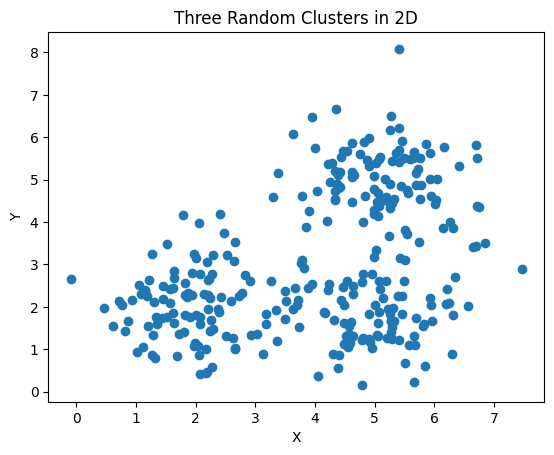

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

# Number of points per cluster
points_per_cluster = 100

# Random cluster centers
centers = np.array([  [2, 2],   [5, 5],   [5, 2]  ])

# Standard deviation of each cluster
cluster_std = 0.8

# Generate clusters
clusters = []
for center in centers:
    cluster = np.random.randn(points_per_cluster, 2) * cluster_std + center
    clusters.append(cluster)

# Combine all clusters into one array
data = np.vstack(clusters)

# Plot clusters
cluster_figure = plt.figure()

plt.scatter(data[:, 0], data[:, 1])

plt.title("Three Random Clusters in 2D")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [2]:
# Follow the K-Means algorithm 

# 1. Determine the number of centroids needed for your data
k = 3

In [3]:
# 2. Randomly assign points to a cluster
assigned_cluster = np.random.randint(0, k, size=len(data))

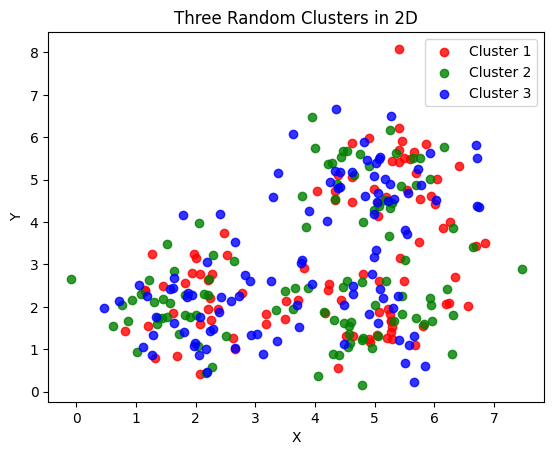

In [4]:
#############
## Let's visualize the random assignment of points to clusters
plt.figure()

colors = ['red', 'green', 'blue']

for i in range(k):
    cluster_points = data[assigned_cluster == i]
    if len(cluster_points) > 0:
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i+1}', alpha=0.8)

plt.title("Three Random Clusters in 2D")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()
##
#############

In [5]:
# 3. Find the center of your clusters and move your centroids to those centers
centroids = []
for i in range(k):
    cluster_points = data[assigned_cluster == i]
    centroids.append(cluster_points.mean(axis=0))

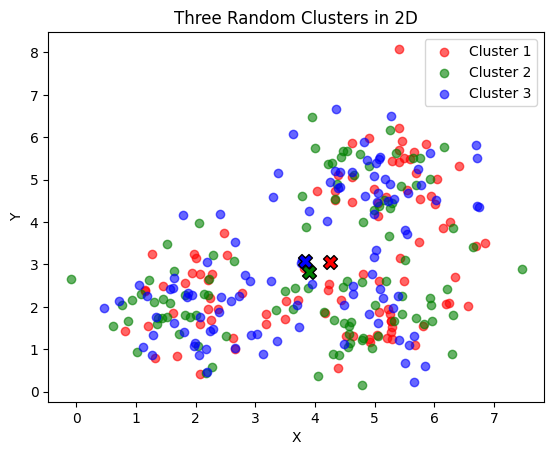

In [6]:
#############
## Let's visualize the random assignment of points to clusters
def visualize_clusters(data, assigned_cluster, centroids):
    plt.figure()
    colors = ['red', 'green', 'blue']
    for i in range(k):
        cluster_points = data[assigned_cluster == i]
        if len(cluster_points) > 0:
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i+1}', alpha=0.6)
        plt.scatter(centroids[i][0], centroids[i][1], c=colors[i], marker='X', edgecolors='black', s=100)

    plt.title("Three Random Clusters in 2D")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

visualize_clusters(data, assigned_cluster, centroids)
##
#############

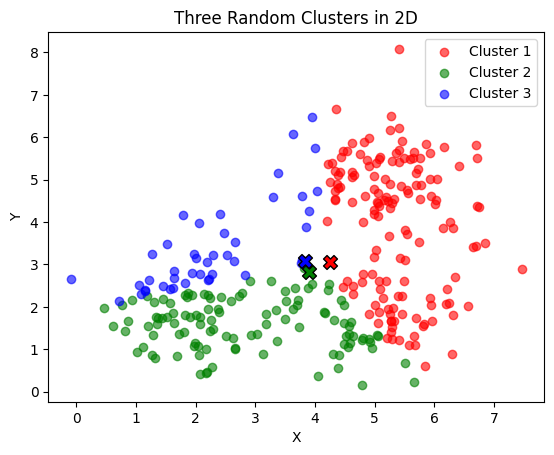

In [7]:
# 4. Measure the distance from every point to each centroid and assign each point to the nearest centroid

def euclidean_distance(point, centroids):
    return np.sqrt(np.sum((point - centroids) ** 2, axis=1))

def assign_clusters(data, centroids):
    new_cluster = np.zeros(len(data), dtype=int)
    for i, point in enumerate(data):
        distances = euclidean_distance(point, centroids)
        new_cluster[i] = np.argmin(distances)
    return new_cluster

assigned_cluster = assign_clusters(data, centroids)

#############
## Let's visualize the new assignment of points to clusters
visualize_clusters(data, assigned_cluster, centroids)
##
###############

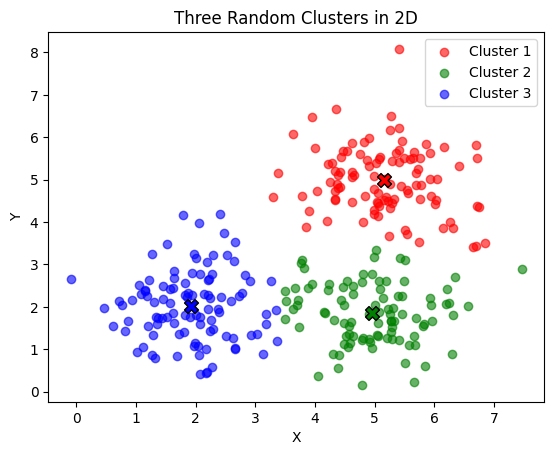

In [15]:
# 5. Repeat steps 3-4 until the updates to your centroids fall below some threshold

## Step 3: Update centroids
centroids = []
for i in range(k):
    cluster_points = data[assigned_cluster == i]
    centroids.append(cluster_points.mean(axis=0))

## Step 4: Reassign clusters
assigned_cluster = assign_clusters(data, centroids)

## Let's visualize the new assignment of points to clusters
visualize_clusters(data, assigned_cluster, centroids)


## Evaulate KMeans with WCSS and Elbow

Let's take a look at our KMeans model with the Elbow Method. We know we created our data with 3 centers, so we expect the WCSS to show an Elbow at $k=3$. Let's see if this is the case.

First, let's create a WCSS function.

In [31]:
def wcss(data, assigned_cluster, centroids):
    total_distance = 0
    for i in range(k):
        cluster_points = data[assigned_cluster == i]
        if len(cluster_points) > 0:
            distances = np.sum((cluster_points - centroids[i]) ** 2, axis=1)
            total_distance += np.sum(distances)
    return total_distance

Now, let's run our model for $k=[1,...,10]$.

In [32]:
# k_values = range(1, 10)
k_values = [3]
wcss_results = []

for k in k_values:
    # Randomly assign points to a cluster
    assigned_cluster = np.random.randint(0, k, size=len(data))
    
    # Update centroids and reassign clusters until convergence
    for _ in range(100):  # Max iterations
        centroids = []
        for i in range(k):
            cluster_points = data[assigned_cluster == i]
            if len(cluster_points) > 0:
                centroids.append(cluster_points.mean(axis=0))
            else:
                centroids.append(np.random.rand(2) * 10)  # Randomly reinitialize empty cluster
        
        new_assigned_cluster = assign_clusters(data, centroids)
        
        if np.array_equal(assigned_cluster, new_assigned_cluster):
            break
        
        assigned_cluster = new_assigned_cluster
    
    wcss_results.append(wcss(data, assigned_cluster, centroids))

Let's see how our different models did.

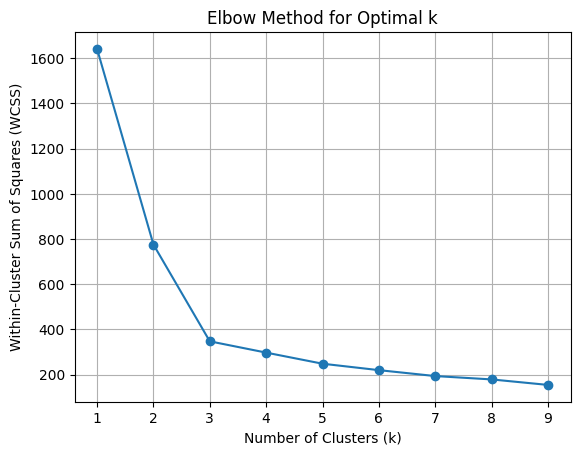

In [28]:
elbow_figure = plt.figure()
plt.plot(k_values, wcss_results, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(k_values)
plt.grid()
plt.show()

The WCSS dropped significantly when $k$ increased from 1 to 2, and again from 2 to 3. But as $k$ increased beyond 3, there was very little gain. So, there was no point in continuing beyond $k=3$.

Now that we have optimized our model, we can publish it. As new data comes in, we just find the nearest centroid and assign the new datapoint to that cluster.